In [2]:
import os
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)

TensorFlow version: 2.21.0
OpenCV version: 4.13.0


In [3]:
# Update this line to the path that actually contains your data
PROJECT_DIR = Path(r"C:\Users\macth\CPSC483_Labs\Emotion-Recognizer-main\Emotion-Recognizer-main")

DATASET_DIR = PROJECT_DIR / "data" / "DATASET"
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

MODEL_DIR = PROJECT_DIR / "models"
LOG_DIR = PROJECT_DIR / "logs"

# This ensures the folders for your saved models and logs are created automatically
current_dir = Path.cwd()

if (current_dir / "data" / "DATASET").exists():
    PROJECT_DIR = current_dir
elif (current_dir.parent / "data" / "DATASET").exists():
    PROJECT_DIR = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find data/DATASET under the current working directory or its parent. "
        "Update PROJECT_DIR to the correct repository folder."
    )

DATASET_DIR = PROJECT_DIR / "data" / "DATASET"
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

MODEL_DIR = PROJECT_DIR / "models"
LOG_DIR = PROJECT_DIR / "logs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)

print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

if TRAIN_DIR.exists():
    print("Train folders:", sorted(os.listdir(TRAIN_DIR)))
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)

# These should both return True now
print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

if TRAIN_DIR.exists():
    print("Train folders:", sorted(os.listdir(TRAIN_DIR)))

Project directory: c:\Users\mpste\CPSC483_Project
Dataset directory: c:\Users\mpste\CPSC483_Project\data\DATASET
Train exists: True
Test exists: True
Train folders: ['1', '2', '3', '4', '5', '6', '7']
Project directory: c:\Users\mpste\CPSC483_Project
Dataset directory: c:\Users\mpste\CPSC483_Project\data\DATASET
Train exists: True
Test exists: True
Train folders: ['1', '2', '3', '4', '5', '6', '7']


In [4]:
emotion_map = {
    "1": "surprise",
    "2": "fear",
    "3": "disgust",
    "4": "happy",
    "5": "sad",
    "6": "angry",
    "7": "neutral"
}

class_names = [
    "surprise",
    "fear",
    "disgust",
    "happy",
    "sad",
    "angry",
    "neutral"
]

print("Emotion classes:")
for key, value in emotion_map.items():
    print(key, "=", value)

Emotion classes:
1 = surprise
2 = fear
3 = disgust
4 = happy
5 = sad
6 = angry
7 = neutral


In [5]:
def count_images(folder):
    rows = []

    for class_folder in sorted(folder.iterdir()):
        if class_folder.is_dir():
            image_files = [
                f for f in class_folder.glob("*")
                if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
            ]

            rows.append({
                "folder_label": class_folder.name,
                "emotion": emotion_map.get(class_folder.name, "unknown"),
                "count": len(image_files)
            })

    return pd.DataFrame(rows)


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training images:")
display(train_counts)

print("Testing images:")
display(test_counts)

print("Total train images:", train_counts["count"].sum())
print("Total test images:", test_counts["count"].sum())

Training images:


,folder_label,emotion,count
0,1,surprise,1290
1,2,fear,281
2,3,disgust,717
3,4,happy,4772
4,5,sad,1982
5,6,angry,705
6,7,neutral,2524


Testing images:


,folder_label,emotion,count
0,1,surprise,329
1,2,fear,74
2,3,disgust,160
3,4,happy,1185
4,5,sad,478
5,6,angry,162
6,7,neutral,680


Total train images: 12271
Total test images: 3068


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.6, 1.4], # Wider range to handle glare
    zoom_range=0.3,              # Zooms in on the mouth/nose area
    channel_shift_range=20.0,    # Randomly shifts colors to ignore glare
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

print("Class indices from Keras:")
print(train_gen.class_indices)

Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
Class indices from Keras:
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}


In [7]:
# 1. Load the pre-trained 'Base' (The cerebral cortex model)
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, # We remove the original 'head' to add our own
    weights="imagenet"
)

# Freeze the base so we don't 'break' its existing knowledge yet
base_model.trainable = False

# 2. Build the 'Head' (The part that learns YOUR specific emotions)
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.45)(x) # Prevents 'memorization' so it works on your face specifically
outputs = layers.Dense(7, activation="softmax")(x) # 7 neurons for 7 emotions

model = models.Model(inputs, outputs)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Slow and steady learning
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,839 (9.89 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
index_to_folder = {v: k for k, v in train_gen.class_indices.items()}
index_to_emotion = {
    index: emotion_map[folder]
    for index, folder in index_to_folder.items()
}

emotion_labels = [
    index_to_emotion[i]
    for i in range(len(index_to_emotion))
]

print("Index to folder:")
print(index_to_folder)

print("Index to emotion:")
print(index_to_emotion)

print("Final emotion label order:")
print(emotion_labels)

Index to folder:
{0: '1', 1: '2', 2: '3', 3: '4', 4: '5', 5: '6', 6: '7'}
Index to emotion:
{0: 'surprise', 1: 'fear', 2: 'disgust', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'neutral'}
Final emotion label order:
['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']


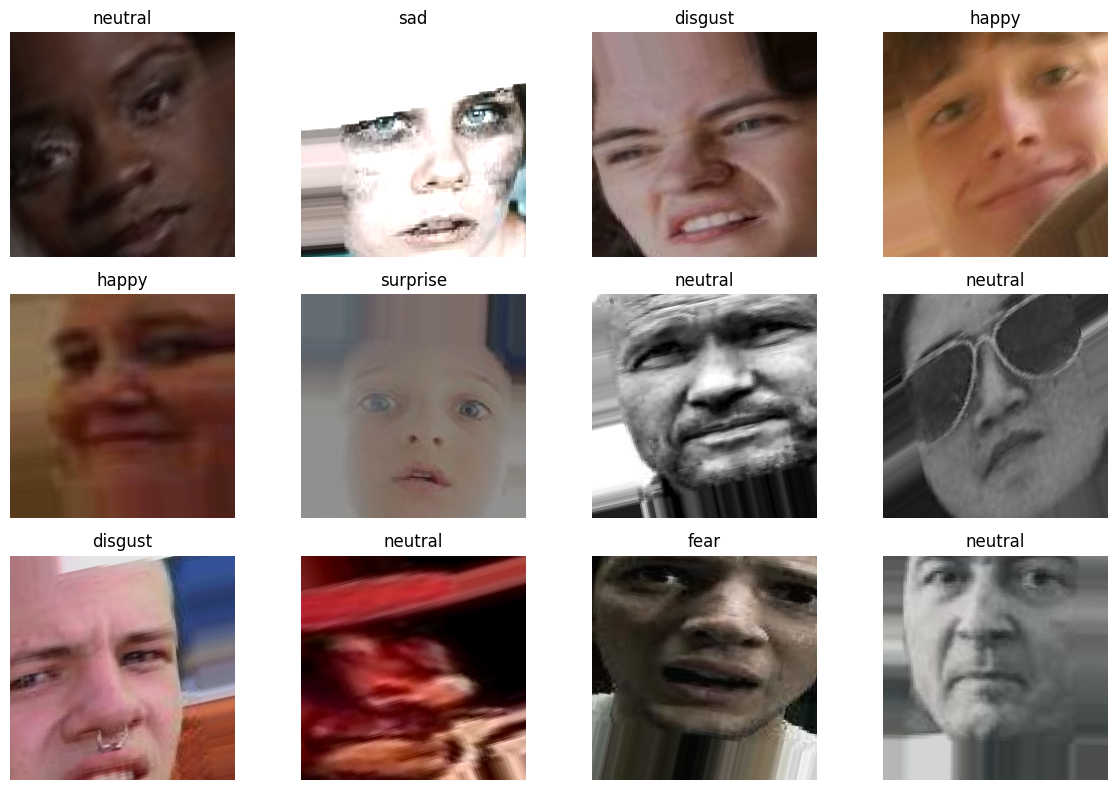

In [10]:
batch_images, batch_labels = next(train_gen)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    # MobileNetV2 preprocessing changes image range to [-1, 1].
    # Convert back to [0, 1] for display.
    img = (batch_images[i] + 1.0) / 2.0
    img = np.clip(img, 0, 1)

    label_index = int(batch_labels[i])
    label_name = emotion_labels[label_index]

    plt.imshow(img)
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
y_train = train_gen.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(y_train), class_weights_array)
}

print("Class weights:")
print(class_weights)

Class weights:
{0: 1.3589147286821706, 1: 6.238434163701068, 2: 2.4449093444909344, 3: 0.3673512154233026, 4: 0.884460141271443, 5: 2.4865248226950354, 6: 0.6945324881141046}


In [24]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.45)(x)

outputs = layers.Dense(7, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,839 (9.89 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [13]:
EPOCHS = 12

checkpoint_path = MODEL_DIR / "best_rafdb_emotion_model.keras"

callbacks = [
    ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - accuracy: 0.2408 - loss: 2.5631
Epoch 1: val_accuracy improved from None to 0.34974, saving model to c:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.2689 - loss: 2.3592 - val_accuracy: 0.3497 - val_loss: 1.7091 - learning_rate: 0.0010
Epoch 2/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.3130 - loss: 1.8738
Epoch 2: val_accuracy improved from 0.34974 to 0.39016, saving model to c:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 367s 955ms/step - accuracy: 0.3224 - loss: 1.8153 - val_accuracy: 0.3902 - val_loss: 1.5958 - learning_rate: 0.0010
Epoch 3/12
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.3621 - loss: 1.6255
Epoch 3: val_accuracy improved from 0.39016 to 0.41851, saving model to c:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 

,accuracy,loss,val_accuracy,val_loss
0,0.466058,1.419009,0.573338,1.186793
1,0.523674,1.307618,0.589961,1.144782
2,0.552115,1.238822,0.610821,1.103612
3,0.571510,1.198302,0.621252,1.073528
4,0.576400,1.164454,0.628422,1.060185
5,0.595306,1.119291,0.632986,1.042277
6,0.601662,1.093361,0.643090,1.011243
7,0.605656,1.077784,0.657106,0.998218
8,0.614783,1.069206,0.649609,0.984771
9,0.624236,1.042355,0.653846,0.973859


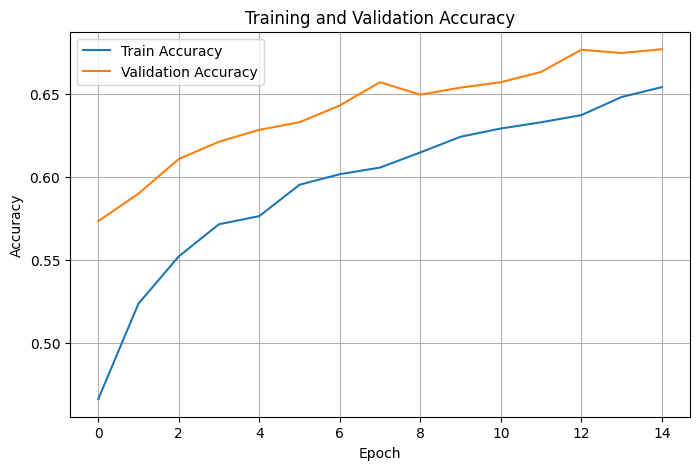

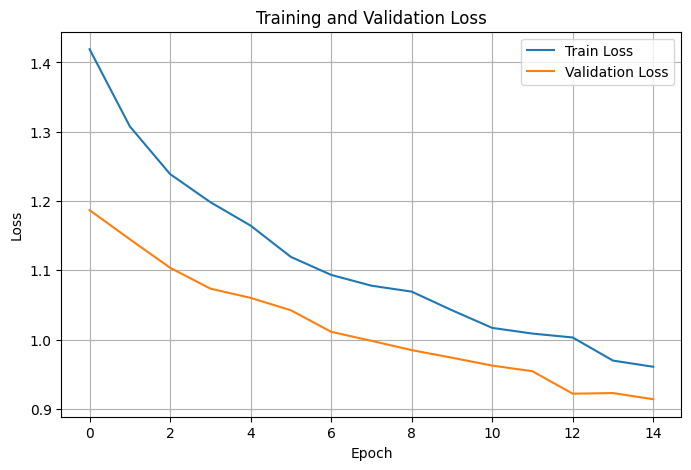

In [25]:
history_df = pd.DataFrame(history.history)

display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5

fine_tune_history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.3587 - loss: 1.6640
Epoch 1: val_accuracy improved from 0.48305 to 0.50554, saving model to c:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 408s 981ms/step - accuracy: 0.3620 - loss: 1.6585 - val_accuracy: 0.5055 - val_loss: 1.4554 - learning_rate: 1.0000e-05
Epoch 2/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - accuracy: 0.3897 - loss: 1.5846
Epoch 2: val_accuracy improved from 0.50554 to 0.53096, saving model to c:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.3939 - loss: 1.5780 - val_accuracy: 0.5310 - val_loss: 1.2930 - learning_rate: 1.0000e-05
Epoch 3/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.4100 - loss: 1.5257
Epoch 3: val_accuracy improved from 0.53096 to 0.54465, saving model to c:\Users\mpste\CPSC483_Project\models\best_rafdb_emotion_model.keras
384/384 ━━━━━━━━━━━━━

In [26]:
if checkpoint_path.exists():
    model = tf.keras.models.load_model(checkpoint_path)
    print("Loaded best checkpoint:", checkpoint_path)

test_loss, test_accuracy = model.evaluate(test_gen)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Loaded best checkpoint: c:\Users\mpste\CPSC483_Project\models\improved_emotion_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 54s 545ms/step - accuracy: 0.6770 - loss: 0.9139
Test loss: 0.913931131362915
Test accuracy: 0.6769882440567017


96/96 ━━━━━━━━━━━━━━━━━━━━ 48s 489ms/step
Classification Report:
              precision    recall  f1-score   support

    surprise       0.73      0.57      0.64       329
        fear       0.81      0.34      0.48        74
     disgust       0.41      0.13      0.20       160
       happy       0.85      0.80      0.82      1185
         sad       0.56      0.62      0.59       478
       angry       0.61      0.51      0.56       162
     neutral       0.55      0.77      0.64       680

    accuracy                           0.68      3068
   macro avg       0.65      0.53      0.56      3068
weighted avg       0.69      0.68      0.67      3068



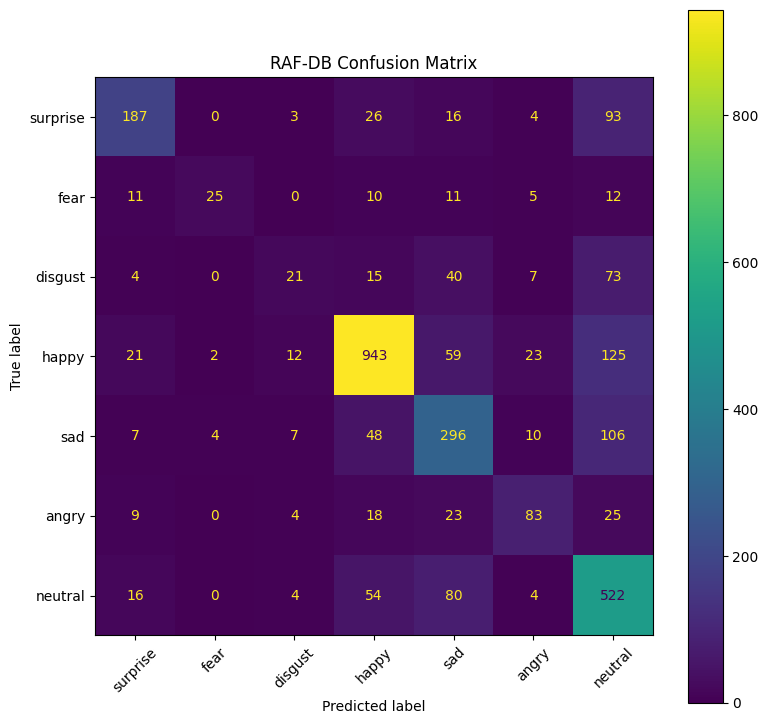

In [27]:
test_gen.reset()

pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=emotion_labels
    )
)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=emotion_labels
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("RAF-DB Confusion Matrix")
plt.show()

In [28]:
final_model_path = MODEL_DIR / "rafdb_emotion_model.keras"
label_path = MODEL_DIR / "emotion_labels.txt"
label_json_path = MODEL_DIR / "emotion_labels.json"

model.save(final_model_path)

with open(label_path, "w", encoding="utf-8") as f:
    for label in emotion_labels:
        f.write(label + "\n")

with open(label_json_path, "w", encoding="utf-8") as f:
    json.dump(emotion_labels, f, indent=4)

print("Saved model to:", final_model_path)
print("Saved labels to:", label_path)
print("Saved labels JSON to:", label_json_path)

Saved model to: c:\Users\mpste\CPSC483_Project\models\rafdb_emotion_model.keras
Saved labels to: c:\Users\mpste\CPSC483_Project\models\emotion_labels.txt
Saved labels JSON to: c:\Users\mpste\CPSC483_Project\models\emotion_labels.json


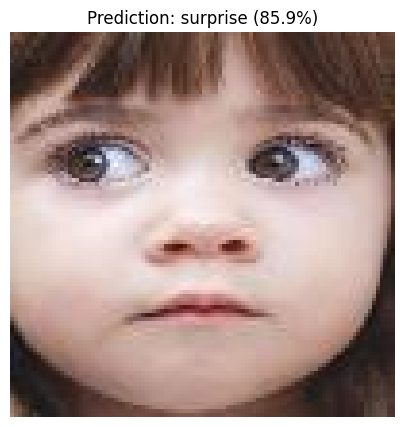

Image: c:\Users\mpste\CPSC483_Project\data\DATASET\test\1\test_0002_aligned.jpg
Predicted emotion: surprise
Confidence: 0.8587231636047363


In [29]:
def predict_single_image(image_path):
    img_bgr = cv2.imread(str(image_path))

    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    x = np.expand_dims(resized.astype(np.float32), axis=0)
    x = preprocess_input(x)

    probs = model.predict(x, verbose=0)[0]
    pred_index = int(np.argmax(probs))

    predicted_emotion = emotion_labels[pred_index]
    confidence = float(probs[pred_index])

    return predicted_emotion, confidence, img_rgb


sample_image = None

for folder in sorted(TEST_DIR.iterdir()):
    if folder.is_dir():
        image_list = [
            p for p in folder.glob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
        ]

        if image_list:
            sample_image = image_list[0]
            break

emotion, confidence, img = predict_single_image(sample_image)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Prediction: {emotion} ({confidence * 100:.1f}%)")
plt.axis("off")
plt.show()

print("Image:", sample_image)
print("Predicted emotion:", emotion)
print("Confidence:", confidence)

In [30]:
import os
from pathlib import Path

# Define the path to your training directory
train_dir = r"C:\Users\macth\CPSC483_Labs\Emotion-Recognizer-main\Emotion-Recognizer-main\data\DATASET\train"

# Add this line so the code knows what the numbers mean
emotion_map = {
    "1": "surprise",
    "2": "fear",
    "3": "disgust",
    "4": "happy",
    "5": "sad",
    "6": "angry",
    "7": "neutral"
}

print("File counts per category:")
print("-" * 30)

train_path = Path(TRAIN_DIR)

print("File counts per category:")
print("-" * 30)

if not train_path.exists():
    print("Train directory not found:", train_path)
else:
    for folder in sorted(train_path.iterdir(), key=lambda p: p.name):
        if folder.is_dir():
            image_files = [
                f for f in folder.iterdir()
                if f.is_file() and f.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")
            ]
            count = len(image_files)
            emotion = emotion_map.get(folder.name, "Unknown")
            print(f"Folder {folder.name} ({emotion}): {count} images")

File counts per category:
------------------------------
File counts per category:
------------------------------
Folder 1 (surprise): 1290 images
Folder 2 (fear): 281 images
Folder 3 (disgust): 717 images
Folder 4 (happy): 4772 images
Folder 5 (sad): 1982 images
Folder 6 (angry): 705 images
Folder 7 (neutral): 2524 images


In [23]:
# 1. Set the number of Epochs (how many times the model looks at the data)
EPOCHS = 15 

# 2. Add Callbacks (Safety features for training)
checkpoint_path = MODEL_DIR / "improved_emotion_model.keras"

callbacks = [
    # Saves the 'best' version of the model if accuracy improves
    tf.keras.callbacks.ModelCheckpoint(filepath=str(checkpoint_path), monitor="val_accuracy", save_best_only=True, verbose=1),
    # Stops training early if the model stops learning (prevents overfitting)
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1)
]

# 3. Start the Training (The 'Learning' Phase)
print("Starting training... This will take a few minutes.")
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Training complete! The best model has been saved to your models folder.")

Starting training... This will take a few minutes.
Epoch 1/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.4501 - loss: 1.4608
Epoch 1: val_accuracy improved from None to 0.57334, saving model to c:\Users\mpste\CPSC483_Project\models\improved_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 357s 931ms/step - accuracy: 0.4661 - loss: 1.4190 - val_accuracy: 0.5733 - val_loss: 1.1868
Epoch 2/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.5167 - loss: 1.3236
Epoch 2: val_accuracy improved from 0.57334 to 0.58996, saving model to c:\Users\mpste\CPSC483_Project\models\improved_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 359s 936ms/step - accuracy: 0.5237 - loss: 1.3076 - val_accuracy: 0.5900 - val_loss: 1.1448
Epoch 3/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.5482 - loss: 1.2504
Epoch 3: val_accuracy improved from 0.58996 to 0.61082, saving model to c:\Users\mpste\CPSC483_Project\models\improved_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 

In [31]:
# Force the model to prioritize 'Disgust' (Index 2) 
# and 'Fear' (Index 1) over the common ones.
custom_class_weights = {
    0: 1.0, # Surprise
    1: 2.0, # Fear (Hard to see, so give it more weight)
    2: 2.5, # Disgust (Very hard to see, give it the most weight)
    3: 1.0, # Happy
    4: 0.8, # Sad (Model is too sensitive to this, so de-prioritize)
    5: 1.2, # Angry
    6: 0.8  # Neutral
}

# Use this in your model.fit()
model.fit(
    train_gen, 
    validation_data=test_gen, 
    epochs=5, 
    class_weight=custom_class_weights
)

Epoch 1/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 359s 923ms/step - accuracy: 0.6546 - loss: 1.1027 - val_accuracy: 0.6776 - val_loss: 0.9159
Epoch 2/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 341s 887ms/step - accuracy: 0.6537 - loss: 1.0745 - val_accuracy: 0.6786 - val_loss: 0.9164
Epoch 3/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 353s 918ms/step - accuracy: 0.6532 - loss: 1.0702 - val_accuracy: 0.6786 - val_loss: 0.9090
Epoch 4/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 364s 949ms/step - accuracy: 0.6637 - loss: 1.0310 - val_accuracy: 0.6744 - val_loss: 0.9232
Epoch 5/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 368s 957ms/step - accuracy: 0.6573 - loss: 1.0316 - val_accuracy: 0.6728 - val_loss: 0.9278


In [32]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Re-freeze everything EXCEPT the last 50 layers
# This allows the model to fine-tune high-level facial features
for layer in base_model.layers[:-50]:
    layer.trainable = False

# 3. Use a VERY small learning rate
# We use 1e-5 (0.00001) so we don't 'destroy' the weights we already learned
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4. Train for 5 more epochs
print("Fine-tuning started... this will make the model much more 'sensitive' to your face.")
model.fit(train_gen, validation_data=test_gen, epochs=5)

# 5. Save this as the 'Final' model
model.save(PROJECT_DIR / "models" / "final_emotion_model.keras")

Fine-tuning started... this will make the model much more 'sensitive' to your face.
Epoch 1/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 350s 895ms/step - accuracy: 0.6742 - loss: 0.9027 - val_accuracy: 0.6874 - val_loss: 0.8812
Epoch 2/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 340s 887ms/step - accuracy: 0.6833 - loss: 0.8799 - val_accuracy: 0.6936 - val_loss: 0.8688
Epoch 3/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 346s 900ms/step - accuracy: 0.6749 - loss: 0.8881 - val_accuracy: 0.6998 - val_loss: 0.8473
Epoch 4/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 359s 934ms/step - accuracy: 0.6959 - loss: 0.8503 - val_accuracy: 0.7021 - val_loss: 0.8450
Epoch 5/5
384/384 ━━━━━━━━━━━━━━━━━━━━ 365s 952ms/step - accuracy: 0.6990 - loss: 0.8378 - val_accuracy: 0.7044 - val_loss: 0.8431
